In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
ticker = 'TSLA' #ticker symbol for Tesla
df = yf.download(
    ticker,
    start='2022-01-01',
    end='2026-01-01',
)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2022-01-03,399.926666,400.356659,378.679993,382.583344,103931400
2022-01-04,383.196655,402.666656,374.350006,396.516663,100248300
2022-01-05,362.706665,390.113342,360.336670,382.216675,80119800
2022-01-06,354.899994,362.666656,340.166656,359.000000,90336600
2022-01-07,342.320007,360.309998,336.666656,360.123322,84164700


In [ ]:
print("shape of dataset:", df.shape) 
df.info() # Display information about the dataset
df.describe() # Display descriptive statistics of the dataset

shape of dataset: (1003, 5)
<class 'pandas.DataFrame'>
DatetimeIndex: 1003 entries, 2022-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   1003 non-null   float64
 1   (High, TSLA)    1003 non-null   float64
 2   (Low, TSLA)     1003 non-null   float64
 3   (Open, TSLA)    1003 non-null   float64
 4   (Volume, TSLA)  1003 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.0 KB


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,1003.000000,1003.000000,1003.000000,1003.000000,1.003000e+03
mean,266.961947,273.070326,260.786308,267.134620,1.041701e+08
std,81.964818,83.665103,80.281850,82.197179,3.861890e+07
min,108.099998,111.750000,101.809998,103.000000,3.625290e+07
25%,204.459999,208.695000,198.445000,204.039993,7.640080e+07
50%,251.449997,257.190002,244.479996,250.869995,9.711340e+07
75%,316.625000,324.395004,309.794998,317.603333,1.226660e+08
max,489.880005,498.829987,485.329987,489.880005,3.065906e+08


In [6]:
df['Next_Close'] = df['Close'].shift(-1) #negative sign predicts the future value of the stock price
df.dropna(inplace=True) #drop the null values
df.head()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,
Date,,,,,,
2022-01-03,399.926666,400.356659,378.679993,382.583344,103931400,362.706665
2022-01-04,383.196655,402.666656,374.350006,396.516663,100248300,354.899994
2022-01-05,362.706665,390.113342,360.336670,382.216675,80119800,342.320007
2022-01-06,354.899994,362.666656,340.166656,359.000000,90336600,352.706665
2022-01-07,342.320007,360.309998,336.666656,360.123322,84164700,354.799988


In [7]:
X = df[['Open', 'High', 'Low', 'Close', 'Volume']] #features used to predict the next closing price
y = df['Next_Close'] #target variable

In [8]:
split_index=int(0.8 * len(df)) #80% of the data for training, 20% for testing
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
model=LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[0.24,0.25,0.24,0.24,0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.074
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[1.11e+09,3.55e+03,1.62e+02,8.87e+01,5.27e+01]"


In [9]:
y_pred=model.predict(X_test)

In [12]:
print("MAE:", mean_absolute_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("R² Score:", r2_score(y_test, y_pred))

MAE: 13.78536127190842
RMSE: 18.029345530390586
R² Score: 0.9371934897761283


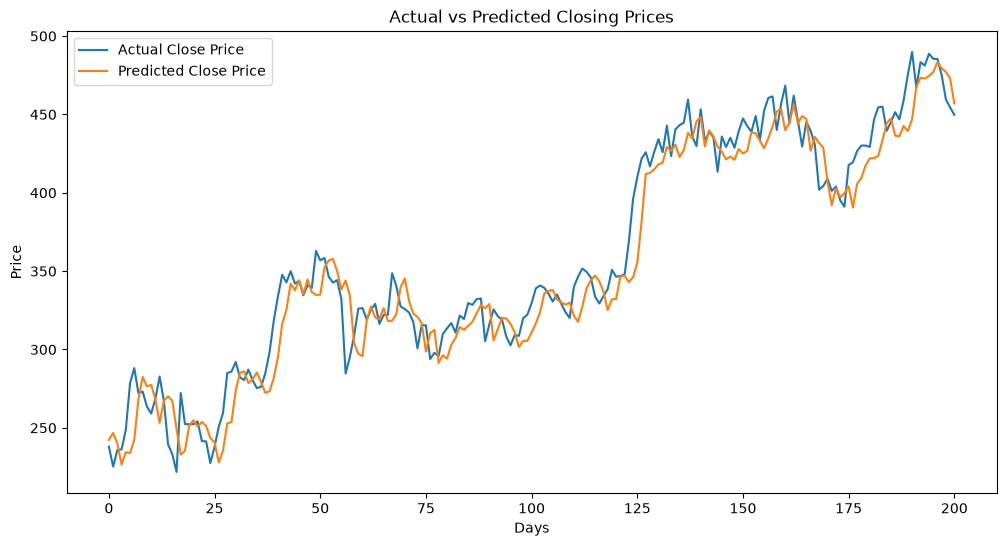

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Close Price") # Plot actual closing prices

plt.plot(y_pred, label="Predicted Close Price") # Plot predicted closing prices

plt.title("Actual vs Predicted Closing Prices") # Set the title of the plot

plt.xlabel("Days") # Set the label for the x-axis

plt.ylabel("Price") # Set the label for the y-axis

plt.legend() # Display the legend

plt.show() # Display the plot